In [ ]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install biopython
!pip install openpyxl
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/ddg_project"

SKEMPI_ROOT = os.path.join(PROJECT_ROOT, "data", "SKEMPI_v2")
EXCEL_PATH = os.path.join(SKEMPI_ROOT, "/content/drive/MyDrive/ddg_project/data/SKEMPI_v2/skempi_v2_with_ddG.xlsx")
PDB_DIR = os.path.join(SKEMPI_ROOT, "/content/drive/MyDrive/ddg_project/data/SKEMPI_v2/pdbs")

ANTIBODY_COMPLEX_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "antibody_complex",
    "6WHA_4HFW.pdb"
)

MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, "paired_ddg_model.pt")

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [ ]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from Bio.PDB import PDBParser, NeighborSearch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

In [ ]:
skempi_df = pd.read_excel(EXCEL_PATH)

print("SKEMPI entries:", len(skempi_df))
skempi_df.head()

SKEMPI entries: 2422


,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85,ddG
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.260000e-11,5.260000e-11,1.120000e-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.279322
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.330000e-12,8.330000e-12,1.120000e-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.188121
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.020000e-07,1.020000e-07,1.120000e-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.761723
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.720000e-10,1.720000e-10,1.120000e-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980860
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.920000e-09,1.920000e-09,1.120000e-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.409415


In [ ]:
import numpy as np
import pandas as pd

# Load the full SKEMPI dataset
skempi_df = pd.read_excel(EXCEL_PATH)

# Extract unique 4-letter PDB IDs
unique_pdbs = skempi_df["#Pdb"].apply(lambda x: x.split("_")[0]).unique()

# Shuffle randomly (reproducible)
np.random.seed(42)
unique_pdbs = np.random.permutation(unique_pdbs)

# Select first 100 PDBs
selected_100 = unique_pdbs[:100]

# Filter dataframe to only include these PDBs
skempi_df = skempi_df[
    skempi_df["#Pdb"].apply(lambda x: x.split("_")[0]).isin(selected_100)
].reset_index(drop=True)

print("Total mutations used:", len(skempi_df))
print("Unique PDBs used:", len(selected_100))

Total mutations used: 1631
Unique PDBs used: 100


In [ ]:
AA_LIST = [
    'ALA','ARG','ASN','ASP','CYS','GLN','GLU','GLY','HIS','ILE',
    'LEU','LYS','MET','PHE','PRO','SER','THR','TRP','TYR','VAL'
]

ONE_TO_THREE_LETTER = {
    'A': 'ALA', 'R': 'ARG', 'N': 'ASN', 'D': 'ASP', 'C': 'CYS',
    'Q': 'GLN', 'E': 'GLU', 'G': 'GLY', 'H': 'HIS', 'I': 'ILE',
    'L': 'LEU', 'K': 'LYS', 'M': 'MET', 'F': 'PHE', 'P': 'PRO',
    'S': 'SER', 'T': 'THR', 'W': 'TRP', 'Y': 'TYR', 'V': 'VAL'
}

def aa_one_hot(resname):
    return [1 if resname == aa else 0 for aa in AA_LIST]

In [ ]:
def build_graph(pdb_path, mutation=None, apply_mutation=False):

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    coords = []
    features = []

    for model in structure:
        for chain in model:
            for res in chain:
                if "CA" not in res:
                    continue

                resname = res.get_resname()
                res_id = res.get_id()[1]
                chain_id = chain.get_id()

                if mutation:
                    mut_chain, mut_pos, mut_res = mutation
                    if chain_id == mut_chain and res_id == mut_pos:
                        if apply_mutation:
                            resname = mut_res

                coords.append(res["CA"].get_coord())
                features.append(aa_one_hot(resname))

    coords = np.vstack(coords).astype(np.float32)
    pos = torch.from_numpy(coords)
    x = torch.tensor(features, dtype=torch.float32)

    dist_matrix = torch.cdist(pos, pos)
    edge_index = (dist_matrix < 8.0).nonzero(as_tuple=False).t()

    return Data(x=x, edge_index=edge_index)

In [ ]:
class SKEMPIPairedDataset(Dataset):

    def __init__(self, dataframe, pdb_dir):
        super().__init__()
        self.df = dataframe
        self.pdb_dir = pdb_dir

    def len(self):
        return len(self.df)

    def get(self, idx):

        row = self.df.iloc[idx]

        pdb_id = row["#Pdb"].split("_")[0]
        mut_str = row["Mutation(s)_cleaned"] # e.g., "LI38G"
        ddg = float(row["ddG"])

        # Parse mut_str (e.g., "LI38G")
        chain_id = mut_str[0] # 'L'
        mut_one_letter = mut_str[-1] # 'G' (mutant one-letter code)

        # Extract wild-type residue and position
        wt_pos_segment = mut_str[1:-1] # "I38"

        # Find the split point between WT residue and position number
        pos_start_idx = -1
        for i, char in enumerate(wt_pos_segment):
            if char.isdigit():
                pos_start_idx = i
                break

        if pos_start_idx == -1: # Handle cases where position might be missing or not numeric
             raise ValueError(f"Could not parse position from mutation string: {mut_str}")

        wt_one_letter = wt_pos_segment[:pos_start_idx] # 'I' (wild-type one-letter code)
        pos = int(wt_pos_segment[pos_start_idx:]) # 38

        # Convert one-letter codes to three-letter codes for the mutation tuple
        mut_three_letter = ONE_TO_THREE_LETTER.get(mut_one_letter.upper(), mut_one_letter)

        pdb_path = os.path.join(self.pdb_dir, f"{pdb_id}.pdb")

        mutation_tuple = (chain_id, pos, mut_three_letter)

        wt_graph = build_graph(pdb_path, mutation_tuple, False)
        mut_graph = build_graph(pdb_path, mutation_tuple, True)

        wt_graph.y = torch.tensor(ddg, dtype=torch.float32)

        return wt_graph, mut_graph

In [ ]:
class DeltaDeltaGModel(nn.Module):

    def __init__(self, input_dim=20, hidden_dim=128):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def encode(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index))
        x = F.relu(self.conv2(x, data.edge_index))
        return global_mean_pool(x, data.batch)

    def forward(self, wt_graph, mut_graph):
        wt_embed = self.encode(wt_graph)
        mut_embed = self.encode(mut_graph)
        diff = mut_embed - wt_embed
        x = F.relu(self.fc1(diff))
        return self.fc2(x).view(-1)

In [ ]:
def train_model(epochs=20, batch_size=8):

    dataset = SKEMPIPairedDataset(skempi_df, PDB_DIR)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = DeltaDeltaGModel().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    y_true, y_pred = [], []

    for epoch in range(epochs):
        total_loss = 0
        model.train()

        for wt_graph, mut_graph in loader:

            wt_graph = wt_graph.to(DEVICE)
            mut_graph = mut_graph.to(DEVICE)

            optimizer.zero_grad()

            pred = model(wt_graph, mut_graph)
            target = wt_graph.y.to(DEVICE)

            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            y_true.extend(target.cpu().numpy())
            y_pred.extend(pred.detach().cpu().numpy())

        print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

    torch.save(model.state_dict(), MODEL_SAVE_PATH)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    pearson_r, _ = pearsonr(y_true, y_pred)

    print(f"\nR²: {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"Pearson r: {pearson_r:.3f}")

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_true, y=y_pred)
    plt.plot([min(y_true), max(y_true)],
             [min(y_true), max(y_true)], 'r--')
    plt.xlabel("Experimental ΔΔG")
    plt.ylabel("Predicted ΔΔG")
    plt.title(f"ΔΔG Regression\nRMSE={rmse:.3f} | R²={r2:.3f} | r={pearson_r:.3f}")
    plt.savefig("ddg_regression.png", dpi=600, bbox_inches='tight')
    plt.show()

    return model

Epoch 1 | Loss: 897.2599
Epoch 2 | Loss: 799.4159
Epoch 3 | Loss: 794.6914
Epoch 4 | Loss: 792.3307
Epoch 5 | Loss: 789.5460
Epoch 6 | Loss: 787.7393
Epoch 7 | Loss: 786.4491
Epoch 8 | Loss: 785.5299
Epoch 9 | Loss: 784.4984
Epoch 10 | Loss: 783.8638
Epoch 11 | Loss: 782.4804
Epoch 12 | Loss: 781.4279
Epoch 13 | Loss: 781.5398
Epoch 14 | Loss: 780.5379
Epoch 15 | Loss: 779.9275
Epoch 16 | Loss: 778.0057
Epoch 17 | Loss: 777.3923
Epoch 18 | Loss: 777.1535
Epoch 19 | Loss: 775.0899
Epoch 20 | Loss: 776.4499
Epoch 21 | Loss: 774.5332
Epoch 22 | Loss: 773.8873
Epoch 23 | Loss: 774.6339
Epoch 24 | Loss: 772.4570
Epoch 25 | Loss: 771.2544
Epoch 26 | Loss: 772.5008
Epoch 27 | Loss: 770.6700
Epoch 28 | Loss: 771.6824
Epoch 29 | Loss: 770.2806
Epoch 30 | Loss: 770.1502
Epoch 31 | Loss: 769.7412
Epoch 32 | Loss: 770.2884
Epoch 33 | Loss: 770.5690
Epoch 34 | Loss: 769.5266
Epoch 35 | Loss: 768.5013
Epoch 36 | Loss: 768.8740
Epoch 37 | Loss: 768.1531
Epoch 38 | Loss: 767.2134
Epoch 39 | Loss: 767.

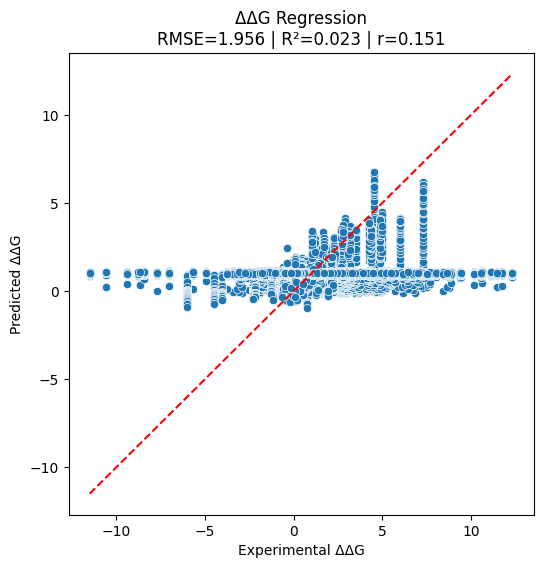

In [ ]:
model = train_model(epochs=40, batch_size=8)

# New Section

# New Section

In [29]:
ANTIBODY_COMPLEX_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "antibody_complex",
    "6WHA_4HFW.pdb"
)

print("Antibody complex path:", ANTIBODY_COMPLEX_PATH)

Antibody complex path: /content/drive/MyDrive/ddg_project/data/antibody_complex/6WHA_4HFW.pdb


In [30]:
from Bio.PDB import NeighborSearch

def detect_interface(pdb_path, antibody_chains, antigen_chains, cutoff=8.0):

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    antibody_atoms = []
    antigen_atoms = []

    for model in structure:
        for chain in model:
            if chain.get_id() in antibody_chains:
                for res in chain:
                    if "CA" in res:
                        antibody_atoms.append(res["CA"])
            elif chain.get_id() in antigen_chains:
                for res in chain:
                    if "CA" in res:
                        antigen_atoms.append(res["CA"])

    ns = NeighborSearch(antigen_atoms)

    interface_res = set()

    for atom in antibody_atoms:
        neighbors = ns.search(atom.coord, cutoff)
        if neighbors:
            residue = atom.get_parent()
            chain_id = residue.get_parent().get_id()
            res_id = residue.get_id()[1]
            interface_res.add((chain_id, res_id))

    interface_res = sorted(interface_res)
    print("Interface residues found:", len(interface_res))

    return interface_res

In [31]:
def interface_mutation_scan(model):

    model.eval()

    ANTIBODY_CHAINS = ["H"]   # adjust if needed
    ANTIGEN_CHAINS = ["A"]         # adjust if needed

    interface_positions = detect_interface(
        ANTIBODY_COMPLEX_PATH,
        ANTIBODY_CHAINS,
        ANTIGEN_CHAINS
    )

    results = []

    for chain_id, pos in interface_positions:
        for aa in AA_LIST:

            mutation_tuple = (chain_id, pos, aa)

            wt_graph = build_graph(ANTIBODY_COMPLEX_PATH, mutation_tuple, False)
            mut_graph = build_graph(ANTIBODY_COMPLEX_PATH, mutation_tuple, True)

            wt_graph = wt_graph.to(DEVICE)
            mut_graph = mut_graph.to(DEVICE)

            with torch.no_grad():
                ddg = model(wt_graph, mut_graph).item()

            results.append({
                "Chain": chain_id,
                "Position": pos,
                "Mutation": aa,
                "Predicted_ddG": ddg
            })

    df = pd.DataFrame(results)

    save_path = os.path.join(PROJECT_ROOT, "interface_mutation_scan_results_6WHA.csv")
    df.to_csv(save_path, index=False)

    print("Saved results to:", save_path)

    return df

In [32]:
def plot_heatmap(df):

    df["Residue"] = df["Chain"] + df["Position"].astype(str)

    heatmap_data = df.pivot(
        index="Residue",
        columns="Mutation",
        values="Predicted_ddG"
    )

    plt.figure(figsize=(14,10))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        center=0,
        linewidths=0.3
    )

    plt.title("Antibody Interface Mutation ΔΔG Heatmap")
    plt.xlabel("Mutation")
    plt.ylabel("Interface Residue")
    plt.tight_layout()
    plt.savefig("6WHA_heatmap.png", dpi=600, bbox_inches='tight')
    plt.show()

Interface residues found: 21
Saved results to: /content/drive/MyDrive/ddg_project/interface_mutation_scan_results_6WHA.csv


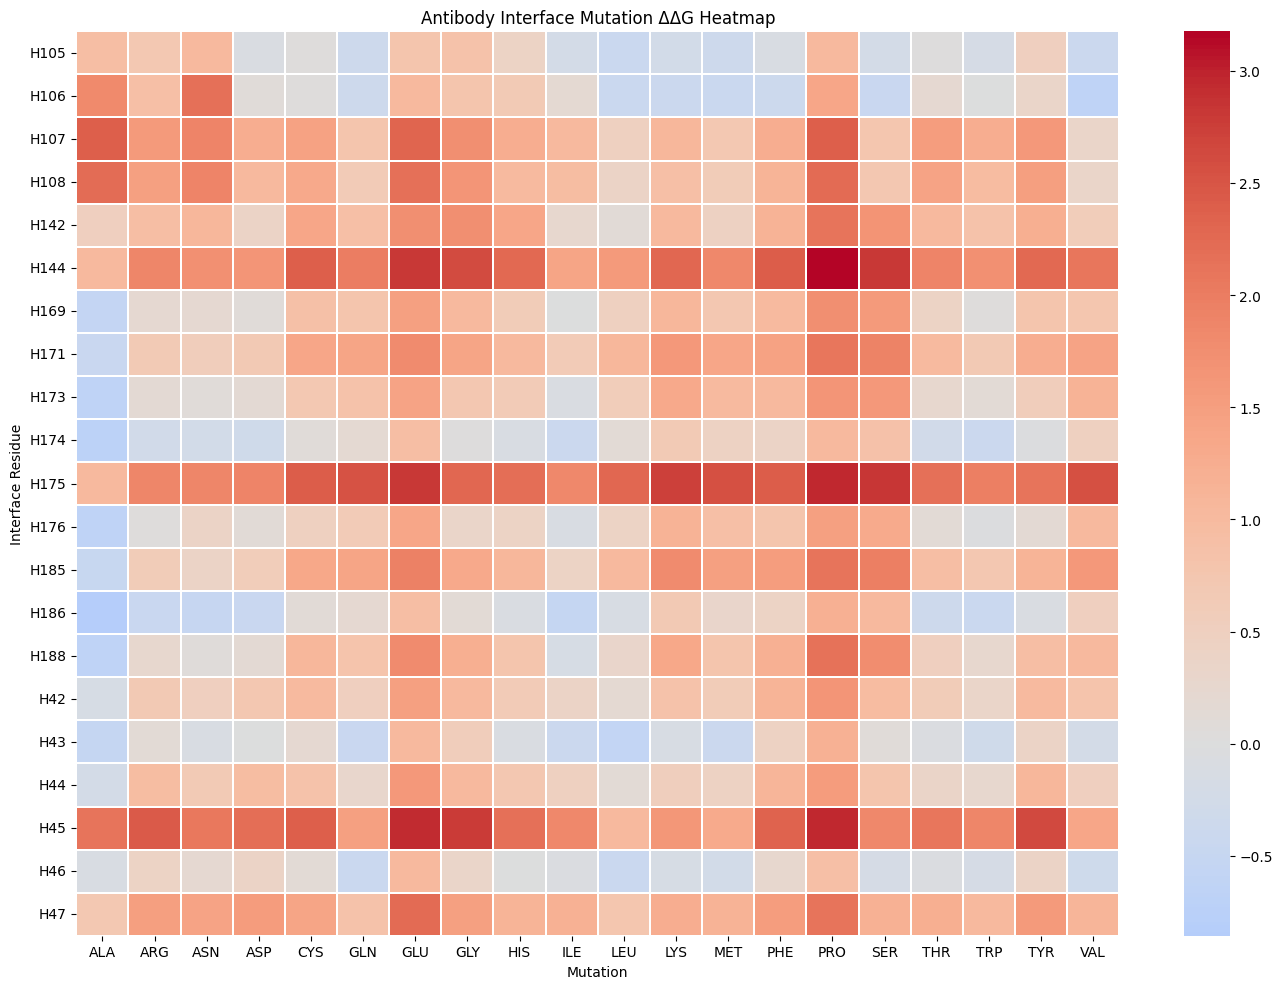

In [33]:
df_interface = interface_mutation_scan(model)

plot_heatmap(df_interface)

In [36]:
ANTIBODY_COMPLEX_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "antibody_complex",
    "6CM4_4HFW.pdb"
)

print("Antibody complex path:", ANTIBODY_COMPLEX_PATH)

Antibody complex path: /content/drive/MyDrive/ddg_project/data/antibody_complex/6CM4_4HFW.pdb


In [37]:
from Bio.PDB import NeighborSearch

def detect_interface(pdb_path, antibody_chains, antigen_chains, cutoff=8.0):

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    antibody_atoms = []
    antigen_atoms = []

    for model in structure:
        for chain in model:
            if chain.get_id() in antibody_chains:
                for res in chain:
                    if "CA" in res:
                        antibody_atoms.append(res["CA"])
            elif chain.get_id() in antigen_chains:
                for res in chain:
                    if "CA" in res:
                        antigen_atoms.append(res["CA"])

    ns = NeighborSearch(antigen_atoms)

    interface_res = set()

    for atom in antibody_atoms:
        neighbors = ns.search(atom.coord, cutoff)
        if neighbors:
            residue = atom.get_parent()
            chain_id = residue.get_parent().get_id()
            res_id = residue.get_id()[1]
            interface_res.add((chain_id, res_id))

    interface_res = sorted(interface_res)
    print("Interface residues found:", len(interface_res))

    return interface_res

In [38]:
def interface_mutation_scan(model):

    model.eval()

    ANTIBODY_CHAINS = ["H"]   # adjust if needed
    ANTIGEN_CHAINS = ["A"]         # adjust if needed

    interface_positions = detect_interface(
        ANTIBODY_COMPLEX_PATH,
        ANTIBODY_CHAINS,
        ANTIGEN_CHAINS
    )

    results = []

    for chain_id, pos in interface_positions:
        for aa in AA_LIST:

            mutation_tuple = (chain_id, pos, aa)

            wt_graph = build_graph(ANTIBODY_COMPLEX_PATH, mutation_tuple, False)
            mut_graph = build_graph(ANTIBODY_COMPLEX_PATH, mutation_tuple, True)

            wt_graph = wt_graph.to(DEVICE)
            mut_graph = mut_graph.to(DEVICE)

            with torch.no_grad():
                ddg = model(wt_graph, mut_graph).item()

            results.append({
                "Chain": chain_id,
                "Position": pos,
                "Mutation": aa,
                "Predicted_ddG": ddg
            })

    df = pd.DataFrame(results)

    save_path = os.path.join(PROJECT_ROOT, "interface_mutation_scan_results_6CM4.csv")
    df.to_csv(save_path, index=False)

    print("Saved results to:", save_path)

    return df

In [39]:
def plot_heatmap(df):

    df["Residue"] = df["Chain"] + df["Position"].astype(str)

    heatmap_data = df.pivot(
        index="Residue",
        columns="Mutation",
        values="Predicted_ddG"
    )

    plt.figure(figsize=(14,10))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        center=0,
        linewidths=0.3
    )

    plt.title("Antibody Interface Mutation ΔΔG Heatmap")
    plt.xlabel("Mutation")
    plt.ylabel("Interface Residue")
    plt.tight_layout()
    plt.savefig("6CM4_heatmap.png", dpi=600, bbox_inches='tight')
    plt.show()

Interface residues found: 32
Saved results to: /content/drive/MyDrive/ddg_project/interface_mutation_scan_results_6CM4.csv


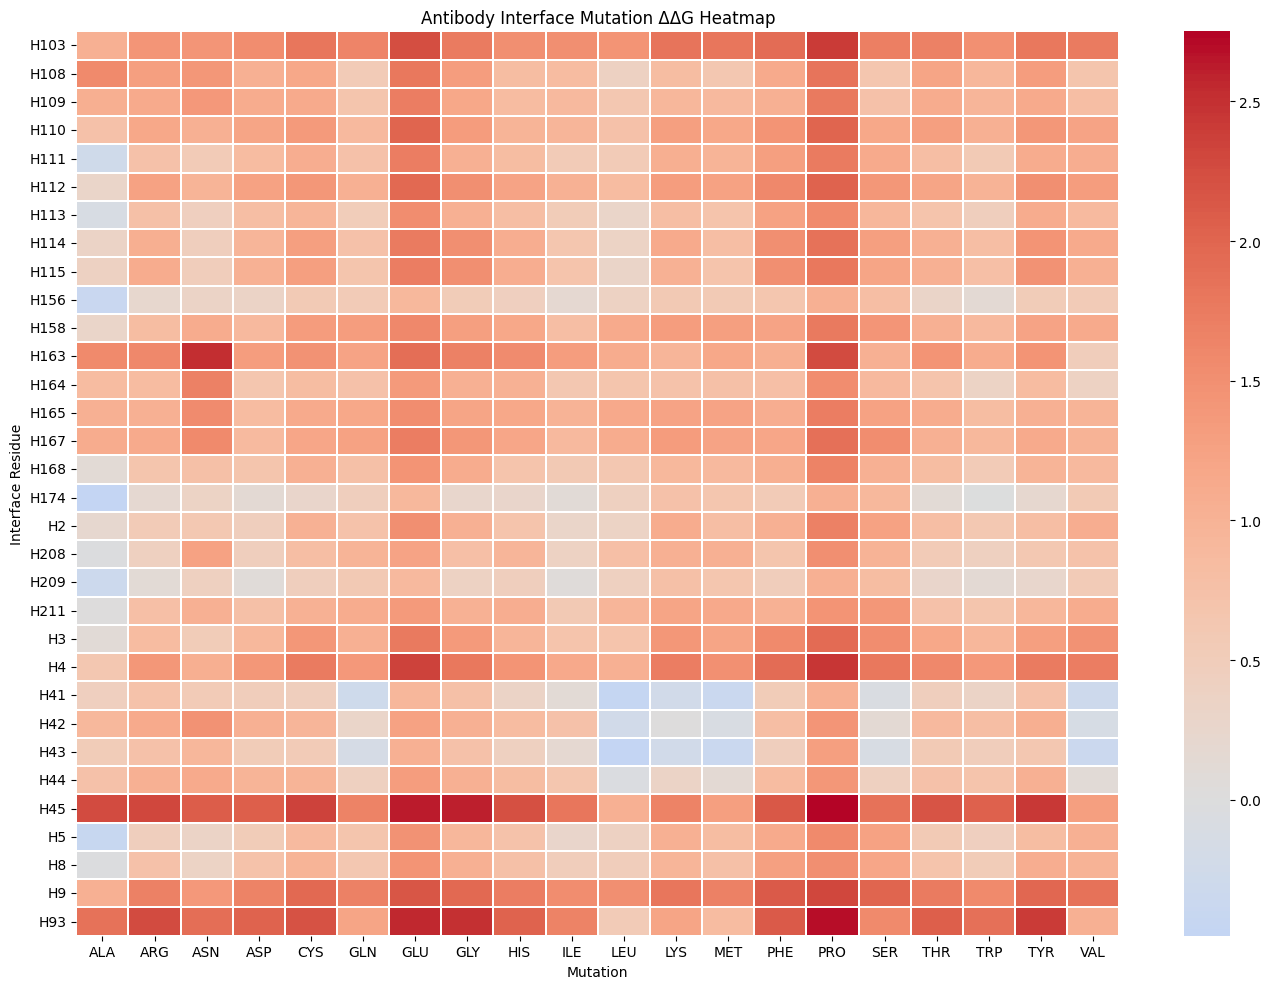

In [40]:
df_interface = interface_mutation_scan(model)

plot_heatmap(df_interface)

In [41]:
ANTIBODY_COMPLEX_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "antibody_complex",
    "6MMB_4HFW.pdb"
)

print("Antibody complex path:", ANTIBODY_COMPLEX_PATH)

Antibody complex path: /content/drive/MyDrive/ddg_project/data/antibody_complex/6MMB_4HFW.pdb


In [42]:
from Bio.PDB import NeighborSearch

def detect_interface(pdb_path, antibody_chains, antigen_chains, cutoff=8.0):

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    antibody_atoms = []
    antigen_atoms = []

    for model in structure:
        for chain in model:
            if chain.get_id() in antibody_chains:
                for res in chain:
                    if "CA" in res:
                        antibody_atoms.append(res["CA"])
            elif chain.get_id() in antigen_chains:
                for res in chain:
                    if "CA" in res:
                        antigen_atoms.append(res["CA"])

    ns = NeighborSearch(antigen_atoms)

    interface_res = set()

    for atom in antibody_atoms:
        neighbors = ns.search(atom.coord, cutoff)
        if neighbors:
            residue = atom.get_parent()
            chain_id = residue.get_parent().get_id()
            res_id = residue.get_id()[1]
            interface_res.add((chain_id, res_id))

    interface_res = sorted(interface_res)
    print("Interface residues found:", len(interface_res))

    return interface_res

In [ ]:
def interface_mutation_scan(model):

    model.eval()

    ANTIBODY_CHAINS = ["H"]   # adjust if needed
    ANTIGEN_CHAINS = ["A"]         # adjust if needed

    interface_positions = detect_interface(
        ANTIBODY_COMPLEX_PATH,
        ANTIBODY_CHAINS,
        ANTIGEN_CHAINS
    )

    results = []

    for chain_id, pos in interface_positions:
        for aa in AA_LIST:

            mutation_tuple = (chain_id, pos, aa)

            wt_graph = build_graph(ANTIBODY_COMPLEX_PATH, mutation_tuple, False)
            mut_graph = build_graph(ANTIBODY_COMPLEX_PATH, mutation_tuple, True)

            wt_graph = wt_graph.to(DEVICE)
            mut_graph = mut_graph.to(DEVICE)

            with torch.no_grad():
                ddg = model(wt_graph, mut_graph).item()

            results.append({
                "Chain": chain_id,
                "Position": pos,
                "Mutation": aa,
                "Predicted_ddG": ddg
            })

    df = pd.DataFrame(results)

    save_path = os.path.join(PROJECT_ROOT, "interface_mutation_scan_results_6MMB.csv")
    df.to_csv(save_path, index=False)

    print("Saved results to:", save_path)

    return df

In [ ]:
def plot_heatmap(df):

    df["Residue"] = df["Chain"] + df["Position"].astype(str)

    heatmap_data = df.pivot(
        index="Residue",
        columns="Mutation",
        values="Predicted_ddG"
    )

    plt.figure(figsize=(14,10))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        center=0,
        linewidths=0.3
    )

    plt.title("Antibody Interface Mutation ΔΔG Heatmap")
    plt.xlabel("Mutation")
    plt.ylabel("Interface Residue")
    plt.tight_layout()
    plt.savefig("6MMB_heatmap.png", dpi=600, bbox_inches='tight')
    plt.show()

Interface residues found: 26
Saved results to: /content/drive/MyDrive/ddg_project/interface_mutation_scan_results_6MMB.csv


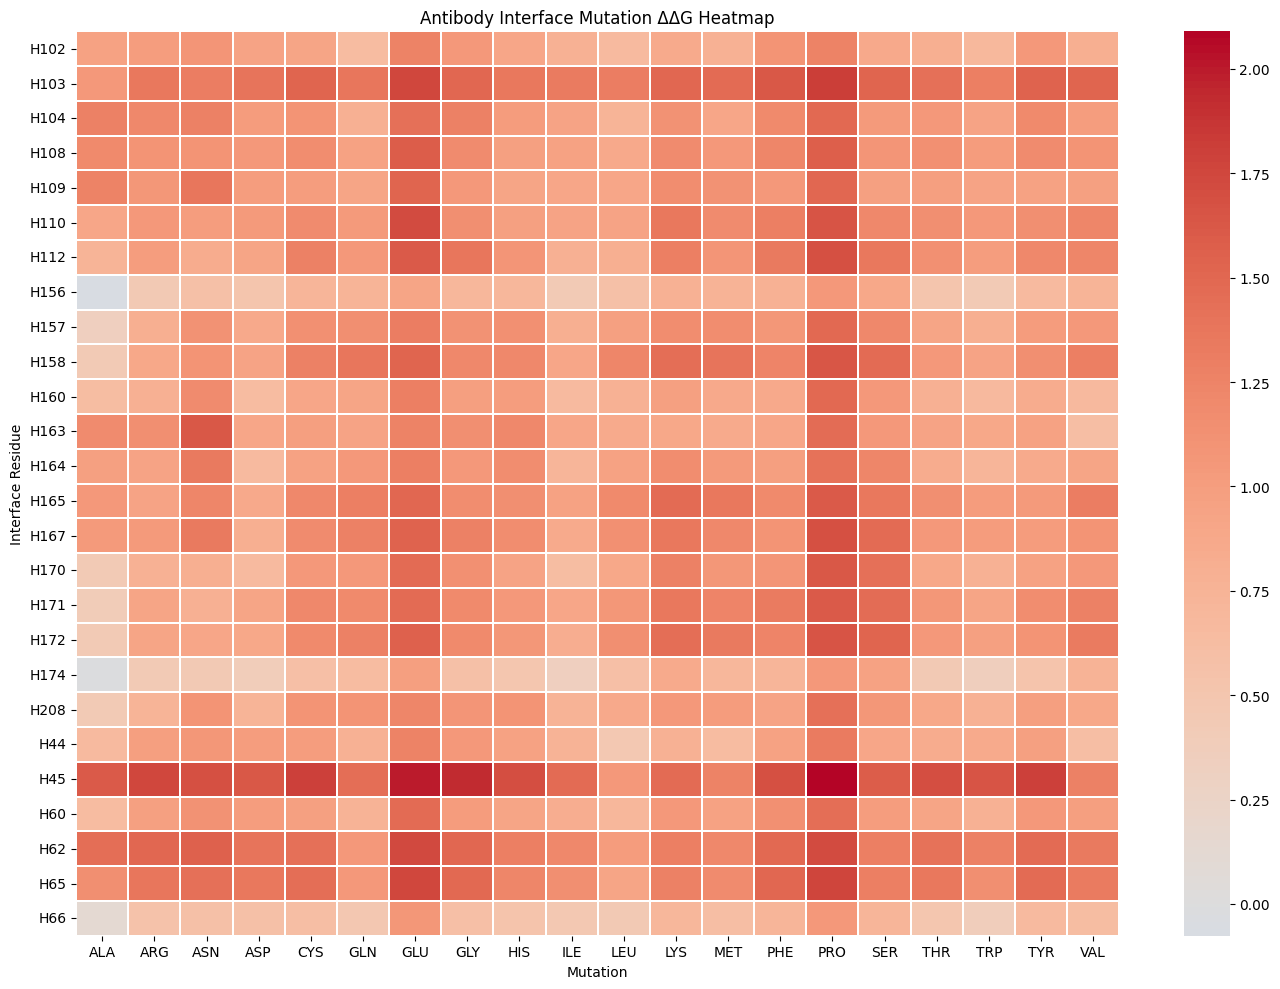

In [ ]:
df_interface = interface_mutation_scan(model)

plot_heatmap(df_interface)